In [2]:
import yfinance as yf
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "^GSPC"]
start_date = "2020-01-01"
end_date = "2026-05-01"
df = yf.download(tickers, start=start_date, end=end_date)['Close']


#yesterday's values
df['AAPL(t-1)'] = df['AAPL'].shift(1)
df['MSFT(t-1)'] = df['MSFT'].shift(1)
df['GOOGL(t-1)'] = df['GOOGL'].shift(1)
df['AMZN(t-1)'] = df['AMZN'].shift(1)
df['TSLA(t-1)'] = df['TSLA'].shift(1)
df['^GSPC(t-1)'] = df['^GSPC'].shift(1)


#"Moving average"
df['AAPL_MA5'] = df['AAPL'].rolling(window=5).mean()
df['MSFT_MA5'] = df['MSFT'].rolling(window=5).mean()
df['GOOGL_MA5'] = df['GOOGL'].rolling(window=5).mean()
df['AMZN_MA5'] = df['AMZN'].rolling(window=5).mean()
df['TSLA_MA5'] = df['TSLA'].rolling(window=5).mean()
df['^GSPC_MA5'] = df['^GSPC'].rolling(window=5).mean()

#set Y Variable  - Next value
df['Target'] = df['AAPL'].shift(-1)
df = df.dropna()
df

C:\Users\louis\AppData\Local\Temp\ipykernel_15124\555492734.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA,^GSPC,AAPL(t-1),MSFT(t-1),GOOGL(t-1),AMZN(t-1),TSLA(t-1),^GSPC(t-1),AAPL_MA5,MSFT_MA5,GOOGL_MA5,AMZN_MA5,TSLA_MA5,^GSPC_MA5,Target
Date,,,,,,,,,,,,,,,,,,,
2020-01-08,73.017838,94.598503,69.676125,151.656342,32.809334,3253.050049,71.861839,149.278564,69.183701,95.343002,31.270666,3237.179932,72.209123,150.801834,68.713678,94.746899,30.480133,3245.842041,74.568779
2020-01-09,74.568779,95.052498,70.407593,153.550949,32.089333,3274.699951,73.017838,151.656342,69.676125,94.598503,32.809334,3253.050049,72.656102,151.080347,69.220592,94.777299,31.161200,3249.212012,74.737373
2020-01-10,74.737373,94.157997,70.862312,152.840454,31.876667,3265.350098,74.568779,153.550949,70.407593,95.052498,32.089333,3274.699951,73.277448,151.595694,69.889464,94.859200,31.629733,3255.312012,76.334091
2020-01-13,76.334091,94.565002,71.411293,154.678253,34.990665,3288.129883,74.737373,152.840454,70.862312,94.157997,31.876667,3265.350098,74.103984,152.400912,70.308205,94.743401,32.607333,3263.681982,75.303314
2020-01-14,75.303314,93.472000,70.943161,153.588867,35.861332,3283.149902,76.334091,154.678253,71.411293,94.565002,34.990665,3288.129883,74.792279,153.262973,70.660097,94.369200,33.525466,3272.875977,74.980629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-23,273.178314,255.080002,338.890015,415.750000,373.720001,7108.399902,272.918579,432.920013,339.320007,255.360001,387.510010,7137.899902,270.960364,422.738007,337.920007,251.838000,388.154004,7109.101953,270.810486
2026-04-24,270.810486,263.989990,344.399994,424.619995,376.299988,7165.080078,273.178314,415.750000,338.890015,255.080002,373.720001,7108.399902,271.126208,423.104004,338.464008,254.523999,383.290002,7116.905957,267.363647
2026-04-27,267.363647,261.119995,350.339996,424.820007,378.670013,7173.910156,270.810486,424.619995,344.399994,263.989990,376.299988,7165.080078,270.039209,424.454004,341.048004,257.091998,380.524005,7129.859961,270.460815


## Step 4 Elastic Net regression : 
- import all the required libraries
- define features and target variables
- train test split
- apply elastic net regression
- get intercept and coeff for Elastic net regression
- Predict using elastic net regression
- create a dataframe with actual and predicted values
- plot
- evaluate the model (r², mse, rmse)

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
X = df.drop(columns=['Target', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', '^GSPC'])
Y = df['Target']

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, shuffle=False)

In [12]:
E_model = ElasticNet(alpha=0.4, l1_ratio=0.2)
E_model.fit(X_train, Y_train) #training the model

c:\Users\louis\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.184e+04, tolerance: 2.856e+02
  model = cd_fast.enet_coordinate_descent(


ElasticNet(alpha=0.4, l1_ratio=0.2)

In [13]:
coefficients = E_model.coef_
intercept = E_model.intercept_
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})
print(coeff_df)

       Feature  Coefficient
0    AAPL(t-1)     0.627008
1    MSFT(t-1)     0.032353
2   GOOGL(t-1)    -0.000000
3    AMZN(t-1)     0.016985
4    TSLA(t-1)     0.000272
5   ^GSPC(t-1)     0.002424
6     AAPL_MA5     0.342412
7     MSFT_MA5    -0.014089
8    GOOGL_MA5     0.005266
9     AMZN_MA5    -0.018297
10    TSLA_MA5    -0.000000
11   ^GSPC_MA5    -0.003086


In [14]:
y_pred = E_model.predict(X_test)
results_df = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred})
print(results_df)

                Actual   Predicted
Date                              
2025-09-11  233.409683  229.407535
2025-09-12  236.032242  231.120135
2025-09-15  237.478149  233.733359
2025-09-16  238.315796  235.887320
2025-09-17  237.208923  237.387339
...                ...         ...
2026-04-23  270.810486  270.907298
2026-04-24  267.363647  270.415893
2026-04-27  270.460815  269.043081
2026-04-28  269.921326  267.094369
2026-04-29  271.100250  268.872552

[159 rows x 2 columns]


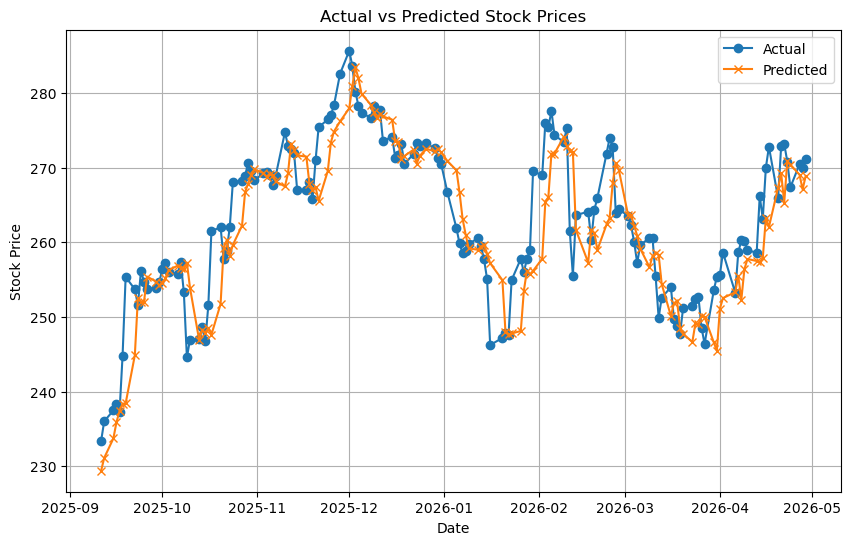

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(Y_test.index, Y_test.values, label='Actual', marker='o')
plt.plot(Y_test.index, y_pred, label='Predicted', marker='x')
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid()
plt.show()

In [16]:
print("R² Score:", r2_score(Y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(Y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(Y_test, y_pred)))

R² Score: 0.7523696421038195
Mean Squared Error: 27.75146146994764
Root Mean Squared Error: 5.267965591188656
